<a href="https://colab.research.google.com/github/vikkystone/Chai-aur-numpy/blob/main/Lab1_EC24BT028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [6]:
import os

print(os.listdir())

['.config', 'PRML Lab-01.pdf', 'insurance (1).csv', 'insurance.csv', 'sample_data']


In [18]:
import pandas as pd

df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

X = df.drop("charges", axis=1)
y = df["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("N =", X.shape[0])
print("d =", X.shape[1])

Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
X shape: (1338, 6)
y shape: (1338,)
N = 1338
d = 6


# if we assume our label/target as charges then its an regression problem because here we dont have to classify items rether for given x vectors we have to caculate expected value which is target

# The dataset can be represented as D=\{(x_i,y_i)\}_{i=1}^{N}, where each x_i belongs to R^d contains the d raw feature values of the i-th sample and y_i is its corresponding label/target(charges).\

# PROBLEM 2

In [23]:
# import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Average charges by smoker
print("Average charges by smoker:")
print(df.groupby("smoker")["charges"].mean())
print()

# Average charges by sex
print("Average charges by sex:")
print(df.groupby("sex")["charges"].mean())
print()

# Average charges by region
print("Average charges by region:")
print(df.groupby("region")["charges"].mean())

# Checking correlation
print("Correlation between age and charges:",
      df["age"].corr(df["charges"]))

print("Correlation between bmi and charges:",
      df["bmi"].corr(df["charges"]))

print("Correlation between children and charges:",
      df["children"].corr(df["charges"]))

Average charges by smoker:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Average charges by sex:
sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64

Average charges by region:
region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64
Correlation between age and charges: 0.29900819333064754
Correlation between bmi and charges: 0.19834096883362895
Correlation between children and charges: 0.0679982268479048


# Histogram of charges

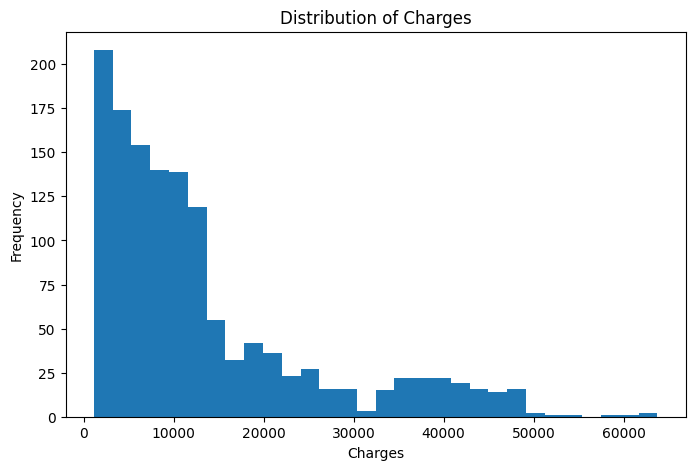

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(df["charges"], bins=30)

plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Charges")

plt.show()

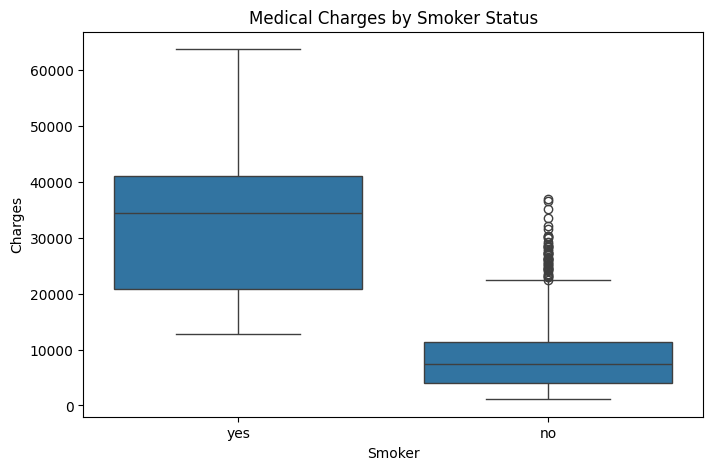

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="smoker", y="charges", data=df)

plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.title("Medical Charges by Smoker Status")

plt.show()

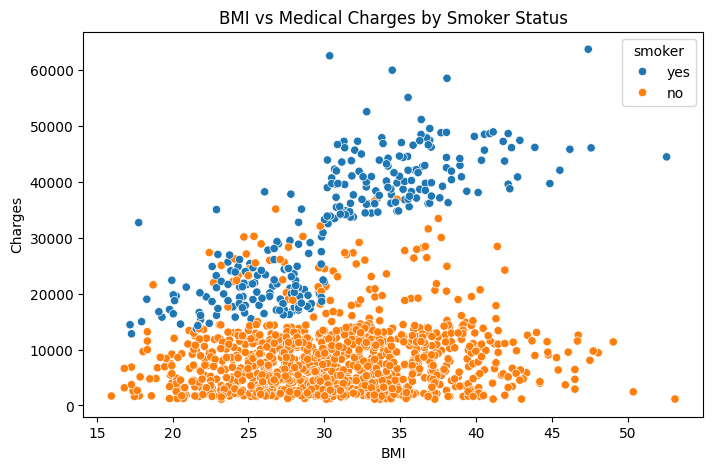

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Medical Charges by Smoker Status")

plt.show()

Index(['age', 'bmi', 'children', 'charges'], dtype='object')


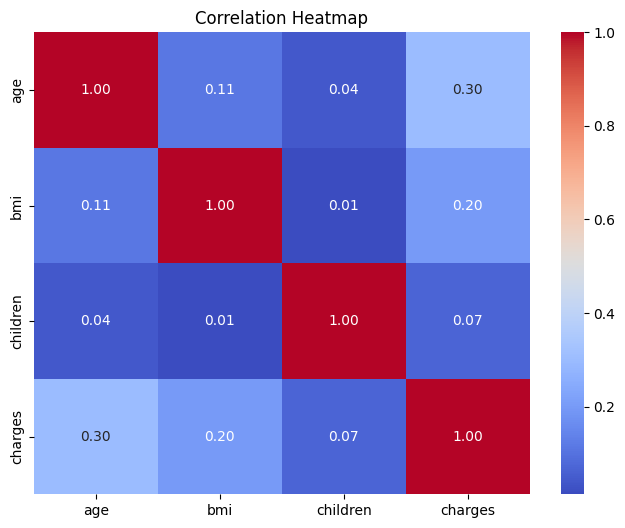

In [29]:
print(df.select_dtypes(include="number").columns)

plt.figure(figsize=(8, 6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Bar chart of average charges by region

Bar chart of average charges by region

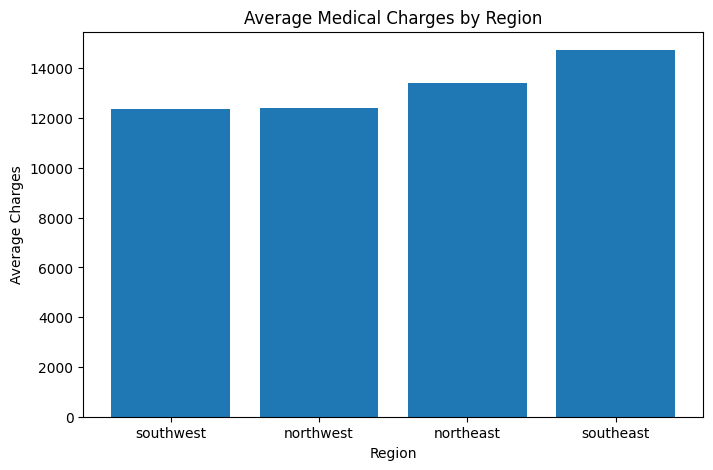

In [30]:
region_avg = df.groupby("region")["charges"].mean().sort_values()

plt.figure(figsize=(8, 5))

plt.bar(region_avg.index, region_avg.values)

plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.title("Average Medical Charges by Region")

plt.show()

# summary

Smoker status appears to be the most important factor among smoker, sex, and region because the difference in mean medical charges between smokers and non-smokers is much larger than the differences across sex or region. Age has the strongest correlation with charges among age, BMI, and children, while BMI has a weaker positive correlation and children has very little linear correlation. The histogram shows that charges are right-skewed, with a small number of individuals having very high medical expenses. The boxplot and BMI-vs-charges scatter plot further show substantially higher charges among smokers, while the regional bar chart indicates comparatively smaller differences in average charges across regions.

# QUESTION 3

In [31]:
import pandas as pd
import numpy as np

# Make a copy of the original dataframe
df_new = df.copy()

# --------------------------------------------------
# 1. BMI Category
# --------------------------------------------------

df_new["bmi_category"] = pd.cut(
    df_new["bmi"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# --------------------------------------------------
# 2. Age Group
# --------------------------------------------------

df_new["age_group"] = pd.cut(
    df_new["age"],
    bins=[0, 18, 30, 45, 60, np.inf],
    labels=["Child", "Young Adult", "Adult", "Middle Aged", "Senior"]
)

# --------------------------------------------------
# 3. Smoker × BMI interaction
# --------------------------------------------------

df_new["smoker_bmi_high"] = (
    (df_new["smoker"] == "yes") &
    (df_new["bmi"] >= 30)
).astype(int)

# --------------------------------------------------
# 4. Family Size
# --------------------------------------------------

df_new["family_size"] = df_new["children"] + 1

# --------------------------------------------------
# 5. BMI × Age interaction
# --------------------------------------------------

df_new["bmi_age_interaction"] = df_new["bmi"] * df_new["age"]

# Show first 10 rows
print(df_new.head(10))

   age     sex     bmi  children smoker     region      charges bmi_category  \
0   19  female  27.900         0    yes  southwest  16884.92400   Overweight   
1   18    male  33.770         1     no  southeast   1725.55230        Obese   
2   28    male  33.000         3     no  southeast   4449.46200        Obese   
3   33    male  22.705         0     no  northwest  21984.47061       Normal   
4   32    male  28.880         0     no  northwest   3866.85520   Overweight   
5   31  female  25.740         0     no  southeast   3756.62160   Overweight   
6   46  female  33.440         1     no  southeast   8240.58960        Obese   
7   37  female  27.740         3     no  northwest   7281.50560   Overweight   
8   37    male  29.830         2     no  northeast   6406.41070   Overweight   
9   60  female  25.840         0     no  northwest  28923.13692   Overweight   

     age_group  smoker_bmi_high  family_size  bmi_age_interaction  
0  Young Adult                0            1       

# BMI Category
Converts continuous BMI into meaningful health-risk groups. The relationship between BMI and medical costs may not be linear, so categories can capture different risk levels.

# age group
Medical expenses can vary substantially between younger and older individuals. Age groups can capture nonlinear age effects that a single numeric age value may not represent well.

# smoker bmi high
Combines smoking status with high BMI. People who are both smokers and have high BMI may have different risk/cost patterns than either factor alone

# family size
Represents the number of people in the individual’s family/dependent group and may capture patterns that are not obvious from children alone.

# bmi_age_interaction
Captures the combined effect of age and BMI. The effect of BMI on medical charges may differ depending on a person’s age.

# QUESTION 4

In [34]:
import numpy as np
import pandas as pd

def custom_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    # Check that ratios add up to 1
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1")

    # Create a random number generator
    rng = np.random.default_rng(seed)

    # Get row indices
    indices = np.arange(len(df))

    # Shuffle indices
    rng.shuffle(indices)

    # Calculate split sizes
    n = len(df)

    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    # Split indices
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]

    # Create DataFrames
    train_df = df.iloc[train_indices].copy()
    val_df = df.iloc[val_indices].copy()
    test_df = df.iloc[test_indices].copy()

    return train_df, val_df, test_df


train_df, val_df, test_df = custom_split(df_new)

print("Training set size:", len(train_df))
print("Validation set size:", len(val_df))
print("Test set size:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

#checking for no overlap
train_indices = set(train_df.index)
val_indices = set(val_df.index)
test_indices = set(test_df.index)

print("Train ∩ Validation:", train_indices.intersection(val_indices))
print("Train ∩ Test:", train_indices.intersection(test_indices))
print("Validation ∩ Test:", val_indices.intersection(test_indices))

no_overlap = (
    train_indices.isdisjoint(val_indices)
    and
    train_indices.isdisjoint(test_indices)
    and
    val_indices.isdisjoint(test_indices)
)

print("No data leakage:", no_overlap)

Training set size: 936
Validation set size: 200
Test set size: 202
Total: 1338
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()
No data leakage: True


# QUESTION 5

In [35]:
import numpy as np
import pandas as pd

# ============================================================
# Q5: CREATE A CORRUPTED COPY
# ============================================================

CORRUPTION_SEED = 12345
np.random.seed(CORRUPTION_SEED)

print("Corruption seed:", CORRUPTION_SEED)

# IMPORTANT: Create a separate copy.
# df_new from Q3 is NOT modified.
corrupted_df = df_new.copy()

# ------------------------------------------------------------
# 1. Introduce missing values in age and bmi
# ------------------------------------------------------------

# 5 missing values total across age and bmi
corrupted_df.loc[[10, 25, 50], "bmi"] = np.nan
corrupted_df.loc[[75, 100], "age"] = np.nan

# ------------------------------------------------------------
# 2. Introduce at least 3 duplicate rows
# ------------------------------------------------------------

duplicate_rows = corrupted_df.iloc[[5, 15, 25]].copy()

corrupted_df = pd.concat(
    [corrupted_df, duplicate_rows],
    ignore_index=True
)

# ------------------------------------------------------------
# 3. Introduce inconsistent text formatting
# ------------------------------------------------------------

# Make sure the columns exist in the dataset
corrupted_df.loc[0, "sex"] = "male"
corrupted_df.loc[1, "sex"] = "Male "
corrupted_df.loc[2, "sex"] = "MALE"

corrupted_df.loc[3, "region"] = "southwest"
corrupted_df.loc[4, "region"] = "Southwest "
corrupted_df.loc[5, "region"] = "SOUTHWEST"

# ------------------------------------------------------------
# 4. Introduce extreme outliers
# ------------------------------------------------------------

# Extreme BMI
corrupted_df.loc[20, "bmi"] = 100

# Extreme charges
corrupted_df.loc[30, "charges"] = 1000000

print("\nCorrupted dataset created.")
print("Shape:", corrupted_df.shape)

Corruption seed: 12345

Corrupted dataset created.
Shape: (1341, 12)


# Cleaning Script

step-1 before cleaning summary



In [36]:
# ============================================================
# BEFORE CLEANING SUMMARY
# ============================================================

print("\n========== BEFORE CLEANING ==========")

print("Shape:", corrupted_df.shape)

print("\nMissing values:")
print(corrupted_df[["age", "bmi"]].isna().sum())

print("\nDuplicate rows:")
print(corrupted_df.duplicated().sum())

print("\nSex values:")
print(corrupted_df["sex"].unique())

print("\nRegion values:")
print(corrupted_df["region"].unique())

print("\nBMI summary:")
print(corrupted_df["bmi"].describe())

print("\nCharges summary:")
print(corrupted_df["charges"].describe())


========== BEFORE CLEANING ==========
Shape: (1341, 12)

Missing values:
age    2
bmi    4
dtype: int64

Duplicate rows:
3

Sex values:
['male' 'Male ' 'MALE' 'female']

Region values:
['southwest' 'southeast' 'Southwest ' 'SOUTHWEST' 'northwest' 'northeast']

BMI summary:
count    1337.000000
mean       30.704858
std         6.387260
min        15.960000
25%        26.220000
50%        30.400000
75%        34.675000
max       100.000000
Name: bmi, dtype: float64

Charges summary:
count       1341.000000
mean       13974.522302
std        29533.290970
min         1121.873900
25%         4719.736550
50%         9377.904700
75%        16586.497710
max      1000000.000000
Name: charges, dtype: float64


step-2  Handle missing values

In [37]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Median is preferred because it is less affected by outliers
corrupted_df["age"] = corrupted_df["age"].fillna(
    corrupted_df["age"].median()
)

corrupted_df["bmi"] = corrupted_df["bmi"].fillna(
    corrupted_df["bmi"].median()
)

print("\nMissing values after imputation:")
print(corrupted_df[["age", "bmi"]].isna().sum())


Missing values after imputation:
age    0
bmi    0
dtype: int64


Step 3 — Remove duplicate rows

In [38]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

before_duplicates = len(corrupted_df)

corrupted_df = corrupted_df.drop_duplicates().reset_index(drop=True)

removed_duplicates = before_duplicates - len(corrupted_df)

print("\nDuplicates removed:", removed_duplicates)
print("Shape after removing duplicates:", corrupted_df.shape)


Duplicates removed: 3
Shape after removing duplicates: (1338, 12)


Step 4 — Standardize text columns

In [39]:
# ============================================================
# STANDARDIZE TEXT COLUMNS
# ============================================================

corrupted_df["sex"] = (
    corrupted_df["sex"]
    .astype(str)
    .str.strip()
    .str.lower()
)

corrupted_df["region"] = (
    corrupted_df["region"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\nStandardized sex values:")
print(corrupted_df["sex"].unique())

print("\nStandardized region values:")
print(corrupted_df["region"].unique())


Standardized sex values:
['male' 'female']

Standardized region values:
['southwest' 'southeast' 'northwest' 'northeast']


Step 5 — Detect outliers using IQR

In [40]:
# ============================================================
# OUTLIER DETECTION USING IQR
# ============================================================

def find_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


# Check BMI
bmi_outliers, bmi_lower, bmi_upper = find_iqr_outliers(
    corrupted_df, "bmi"
)

# Check charges
charges_outliers, charges_lower, charges_upper = find_iqr_outliers(
    corrupted_df, "charges"
)

print("\n========== OUTLIER DETECTION ==========")

print("\nBMI:")
print("Lower bound:", bmi_lower)
print("Upper bound:", bmi_upper)
print("Number of outliers:", len(bmi_outliers))

print("\nCharges:")
print("Lower bound:", charges_lower)
print("Upper bound:", charges_upper)
print("Number of outliers:", len(charges_outliers))


========== OUTLIER DETECTION ==========

BMI:
Lower bound: 13.756250000000001
Upper bound: 47.19625
Number of outliers: 10

Charges:
Lower bound: -13109.1508975
Upper bound: 34489.350562499996
Number of outliers: 139


Step 6 — Handle the outliers

In [41]:
# ============================================================
# HANDLE OUTLIERS USING IQR CAPPING
# ============================================================

corrupted_df["bmi"] = corrupted_df["bmi"].clip(
    lower=bmi_lower,
    upper=bmi_upper
)

corrupted_df["charges"] = corrupted_df["charges"].clip(
    lower=charges_lower,
    upper=charges_upper
)

print("\nOutliers handled using IQR capping.")


Outliers handled using IQR capping.


Step 7 — After-cleaning summary

In [42]:
# ============================================================
# AFTER CLEANING SUMMARY
# ============================================================

print("\n========== AFTER CLEANING ==========")

print("Shape:", corrupted_df.shape)

print("\nMissing values:")
print(corrupted_df.isna().sum())

print("\nDuplicate rows:")
print(corrupted_df.duplicated().sum())

print("\nSex values:")
print(corrupted_df["sex"].unique())

print("\nRegion values:")
print(corrupted_df["region"].unique())

print("\nBMI summary:")
print(corrupted_df["bmi"].describe())

print("\nCharges summary:")
print(corrupted_df["charges"].describe())


========== AFTER CLEANING ==========
Shape: (1338, 12)

Missing values:
age                    0
sex                    0
bmi                    0
children               0
smoker                 0
region                 0
charges                0
bmi_category           0
age_group              0
smoker_bmi_high        0
family_size            0
bmi_age_interaction    0
dtype: int64

Duplicate rows:
0

Sex values:
['male' 'female']

Region values:
['southwest' 'southeast' 'northwest' 'northeast']

BMI summary:
count    1338.000000
mean       30.655364
std         6.068547
min        15.960000
25%        26.296250
50%        30.400000
75%        34.656250
max        47.196250
Name: bmi, dtype: float64

Charges summary:
count     1338.000000
mean     12480.951507
std      10156.531151
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      34489.350562
Name: charges, dtype: float64


# QUESTION - 6

1. Scale age and bmi

In [43]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Q6 uses the ORIGINAL, uncorrupted Q3 dataframe
# and the train/validation/test splits from Q4.

# Select input features
features = ["age", "bmi"]

X_train = train_df[features].copy()
X_val = val_df[features].copy()
X_test = test_df[features].copy()

# Create scaler
scaler = StandardScaler()

# IMPORTANT:
# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME training parameters to validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=train_df.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=features,
    index=val_df.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=test_df.index
)

print("Training scaled data:")
print(X_train_scaled.head())

print("\nValidation scaled data:")
print(X_val_scaled.head())

print("\nTest scaled data:")
print(X_test_scaled.head())

Training scaled data:
           age       bmi
974  -0.969005  0.797379
86    1.227437  0.103591
1174 -0.756446  0.258309
1133  0.873172 -1.985104
776   0.022936  0.289253

Validation scaled data:
           age       bmi
1165 -0.331328 -0.716415
958   0.235495  0.722463
1270 -0.969005  0.552273
963   0.448054 -0.933020
882  -1.323270 -1.366231

Test scaled data:
          age       bmi
948  0.164642  0.119063
391 -1.464976  1.124730
165  0.518907 -0.376035
449 -0.331328  1.315278
838 -0.331328 -1.149626


2. Verify that scaling was learned from training data

In [44]:
print("Training means:")
print(X_train_scaled.mean())

print("\nTraining standard deviations:")
print(X_train_scaled.std())

Training means:
age    1.897817e-17
bmi    1.328472e-17
dtype: float64

Training standard deviations:
age    1.000535
bmi    1.000535
dtype: float64


3. Confirm that charges was not scaled

In [45]:
y_train = train_df["charges"].copy()
y_val = val_df["charges"].copy()
y_test = test_df["charges"].copy()

print("Target:", y_train.name)

Target: charges


4. Plot BMI before and after scaling

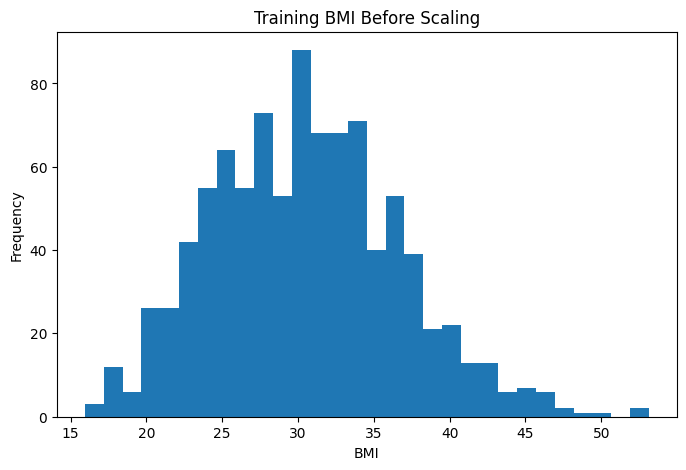

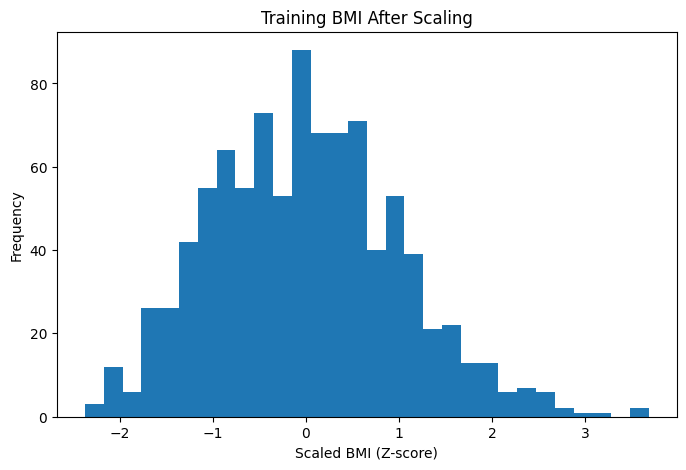

In [51]:
plt.figure(figsize=(8, 5))

plt.hist(
    X_train["bmi"],
    bins=30
)

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Training BMI Before Scaling")

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    X_train_scaled["bmi"],
    bins=30
)

plt.xlabel("Scaled BMI (Z-score)")
plt.ylabel("Frequency")
plt.title("Training BMI After Scaling")

plt.show()

5. Why not fit the scaler on the full dataset?

The scaler should be fitted only on the training set because the validation and test sets must remain unseen during model development. If the scaler is fitted on the full dataset, information about the distributions of the validation and test data, such as their mean and standard deviation, leaks into the training process. This can make the evaluation overly optimistic because the preprocessing has indirectly used information from data that should have been unseen. Therefore, the training-set scaling parameters must be learned once and then applied unchanged to the validation and test sets.